# Timeseries forecasting for weather prediction


## Setup

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import keras

## Climate Data Time-Series

We will be using Jena Climate dataset recorded by the
[Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/).
The dataset consists of 14 features such as temperature, pressure, humidity etc, recorded once per
10 minutes.

**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016


The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [11]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

## Raw Data Visualization

To give us a sense of the data we are working with, each feature has been plotted below.
This shows the distinct pattern of each feature over the time period from 2009 to 2016.
It also shows where anomalies are present, which will be addressed during normalization.

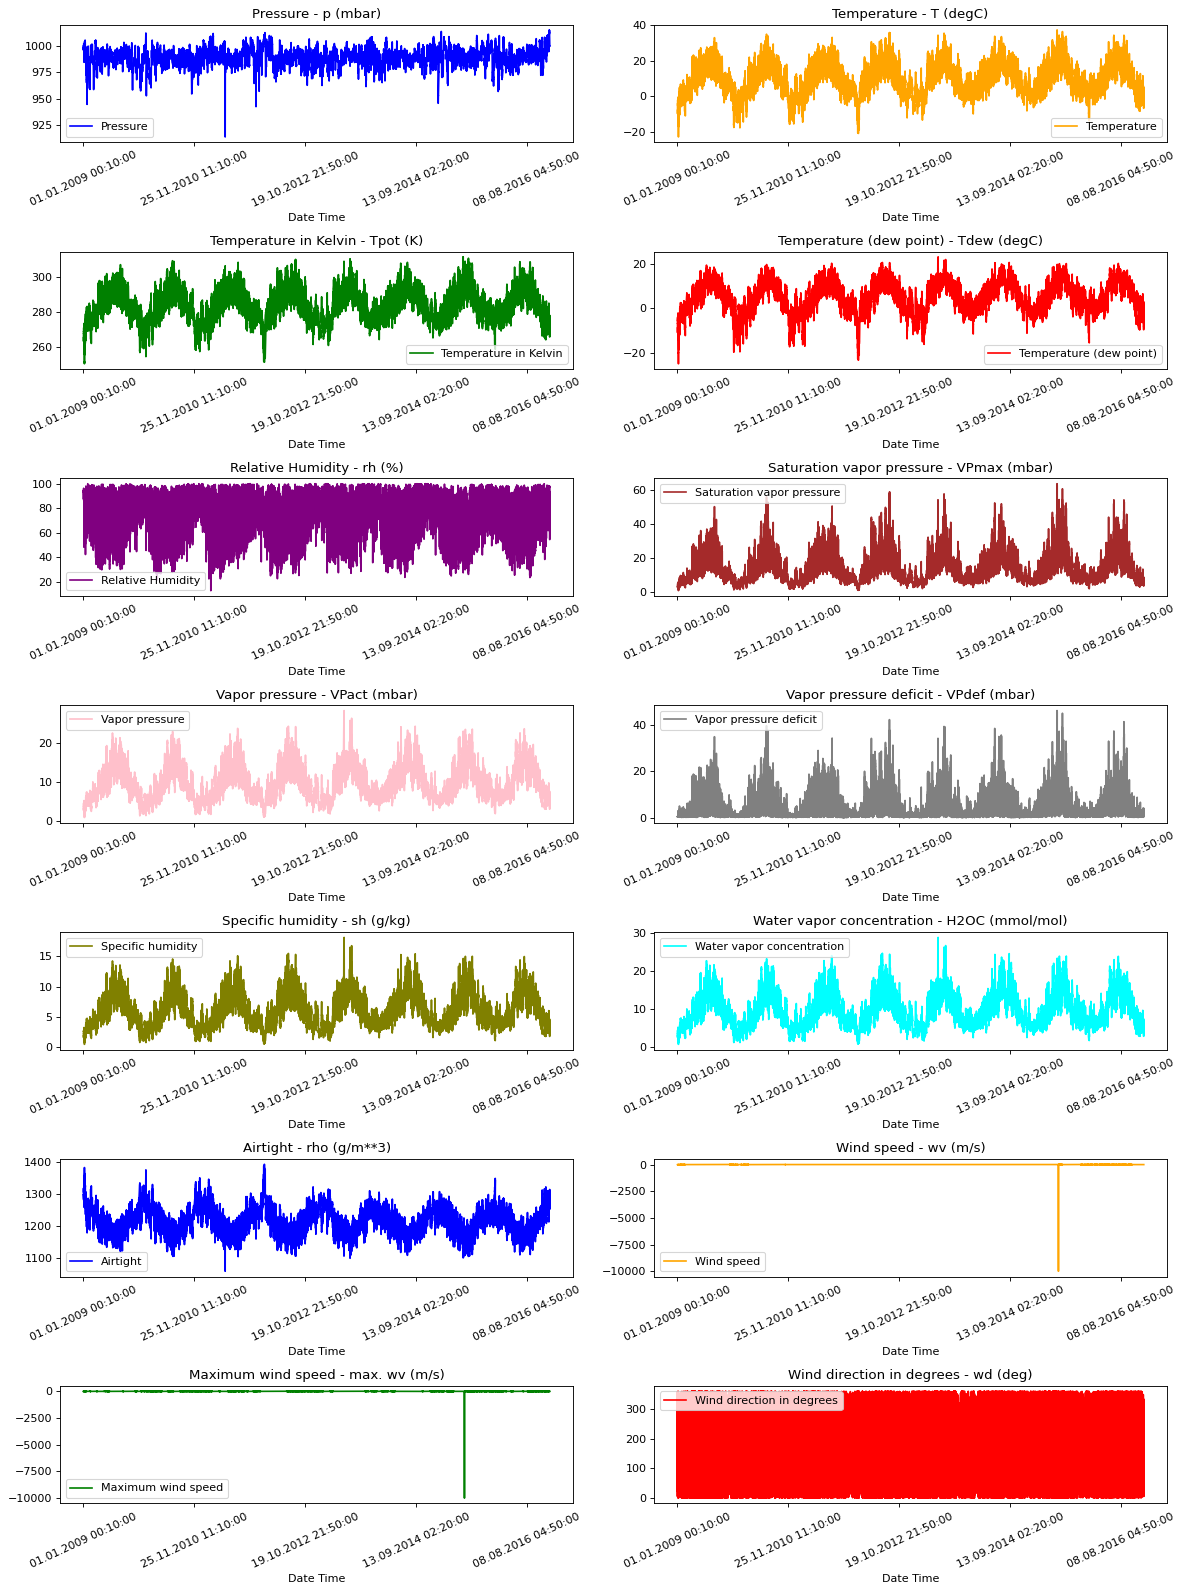

In [12]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)

## Data Preprocessing

Here we are picking ~300,000 data points for training. Observation is recorded every
10 mins, that means 6 times per hour. We will resample one point per hour since no
drastic change is expected within 60 minutes. We do this via the `sampling_rate`
argument in `timeseries_dataset_from_array` utility.

We are tracking data from past 720 timestamps (720/6=120 hours). This data will be
used to predict the temperature after 72 timestamps (72/6=12 hours).

Since every feature has values with
varying ranges, we do normalization to confine feature values to a range of `[0, 1]` before
training a neural network.
We do this by subtracting the mean and dividing by the standard deviation of each feature.

71.5 % of the data will be used to train the model, i.e. 300,693 rows. `split_fraction` can
be changed to alter this percentage.

The model is shown data for first 5 days i.e. 720 observations, that are sampled every
hour. The temperature after 72 (12 hours * 6 observation per hour) observation will be
used as a label.

In [13]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10


def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

We can see from the correlation heatmap, few parameters like Relative Humidity and
Specific Humidity are redundant. Hence we will be using select features, not all.

In [14]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


# Training dataset

The training dataset labels starts from the 792nd observation (720 + 72).

In [15]:
start = past + future
end = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

The `timeseries_dataset_from_array` function takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as length of the
sequences/windows, spacing between two sequence/windows, etc., to produce batches of
sub-timeseries inputs and targets sampled from the main timeseries.

In [16]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

## Validation dataset

The validation dataset must not contain the last 792 rows as we won't have label data for
those records, hence 792 must be subtracted from the end of the data.

The validation label dataset must start from 792 after train_split, hence we must add
past + future (792) to label_start.

In [17]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


## Training baseline

In [18]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

We'll use the `ModelCheckpoint` callback to regularly save checkpoints, and
the `EarlyStopping` callback to interrupt training when the validation loss
is not longer improving.

In [19]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2960
Epoch 1: val_loss improved from None to 0.14920, saving model to model_checkpoint.weights.h5

Epoch 1: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 71s 58ms/step - loss: 0.1920 - val_loss: 0.1492
Epoch 2/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1387
Epoch 2: val_loss improved from 0.14920 to 0.13395, saving model to model_checkpoint.weights.h5

Epoch 2: finished saving model to model_checkpoint.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.1227 - val_loss: 0.1340
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1206
Epoch 3: val_loss did not improve from 0.13395
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - loss: 0.1124 - val_loss: 0.1389
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1183
Epoch 4: val_loss did not improve from 0.13395
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - loss: 0.1098 - val_loss: 0.

Save training history and model to be able to compare later on.

In [20]:
import pickle

with open("/content/history.pkl", "wb") as f:
    pickle.dump(history.history, f)
model.save("/content/model.keras")

We can visualize the loss with the function below. After one point, the loss stops
decreasing.

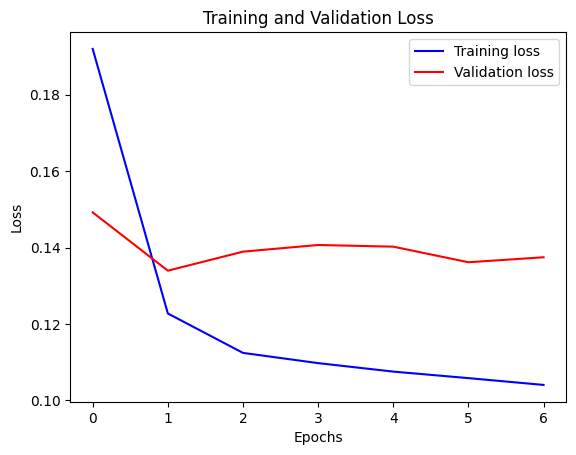

In [21]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


visualize_loss(history, "Training and Validation Loss")

## Prediction

The trained model above is now able to make predictions for 5 sets of values from
validation set.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


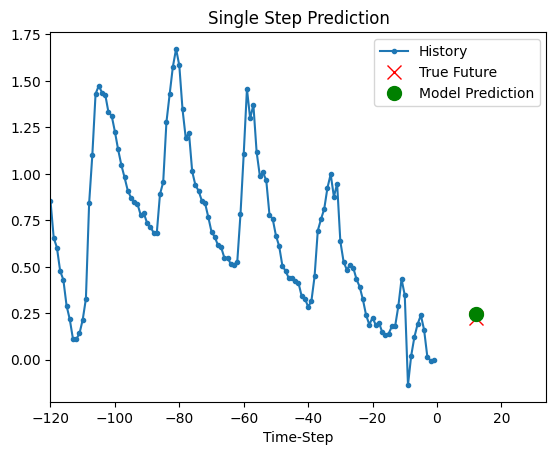

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


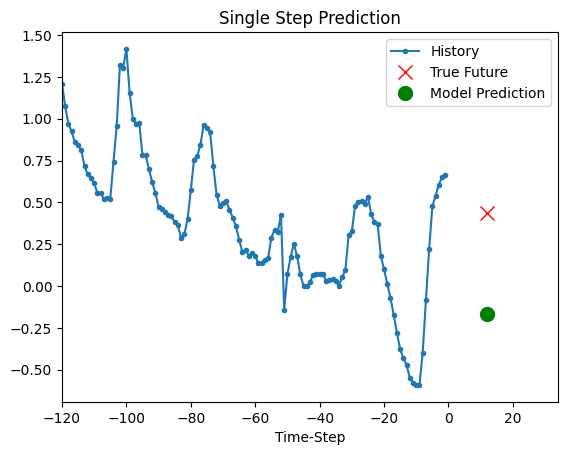

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


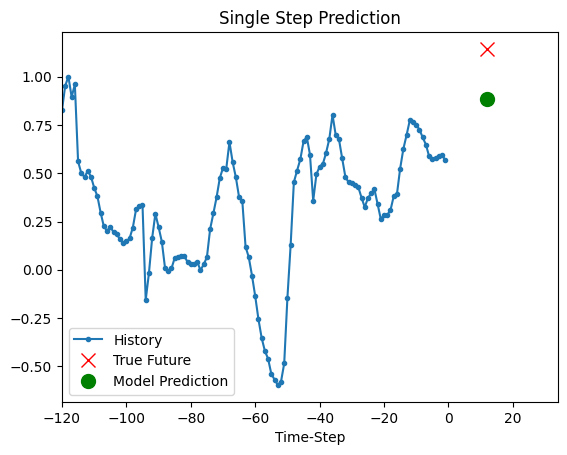

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


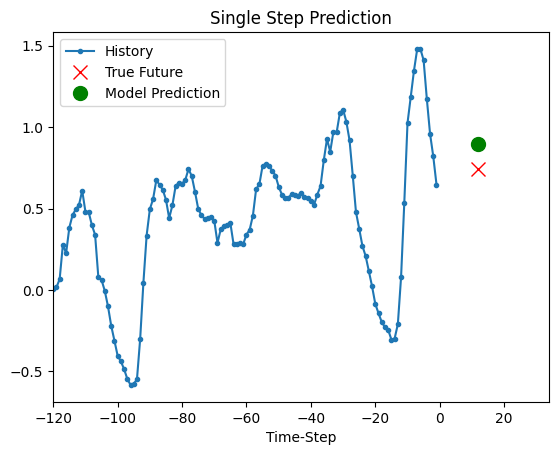

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


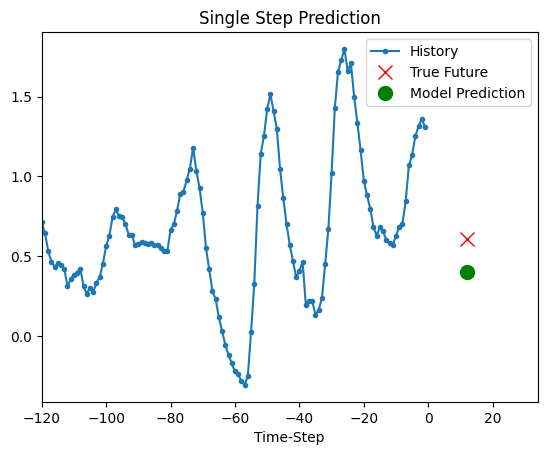

In [22]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return


for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

## Evaluation

In [23]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get true values from dataset_val
y_true = np.concatenate([y.numpy() for x, y in dataset_val], axis=0)

# Get predictions
y_pred = model.predict(dataset_val)

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2  :", r2)

463/463 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step
MSE : 0.1374642903991688
MAE : 0.2912387000241399
RMSE: 0.3707617704121729
R^2  : 0.833568575429508


# Improved version of baseline model

To improve the baseline model, three modifications were introduced:

- Increase LSTM hidden size (32 → 64):
The number of units in the LSTM layer was increased to allow the model to capture more complex temporal patterns in the data.
- Add Dropout:
A dropout layer was added after the LSTM to reduce overfitting by preventing the model from relying too heavily on specific neurons.
- Change input sequence length:
The length of the input sequence (past) was modified to study how the amount of historical data affects performance. Reducing the input sequence length may help the model focus on more recent and relevant patterns while reducing noise from older observations.

These changes aim to improve both the model’s capacity and its ability to generalize to unseen data.

## Data preparation

Run necessary cells again to change the past from 720 to 360

In [24]:
past = 360 # Change past

In [25]:
start = past + future
end = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

In [26]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [27]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 60, 7)
Target shape: (256, 1)


## Training the improved model

In [28]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
x = keras.layers.LSTM(64)(inputs)   # changed from 32 to 64
x = keras.layers.Dropout(0.2)(x)    # added
outputs = keras.layers.Dense(1)(x)

model_improved = keras.Model(inputs=inputs, outputs=outputs)
model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mse"
)
model_improved.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_improved = model_improved.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2653
Epoch 1: val_loss improved from None to 0.15326, saving model to model_checkpoint.weights.h5

Epoch 1: finished saving model to model_checkpoint.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 66s 55ms/step - loss: 0.1741 - val_loss: 0.1533
Epoch 2/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1570
Epoch 2: val_loss improved from 0.15326 to 0.14383, saving model to model_checkpoint.weights.h5

Epoch 2: finished saving model to model_checkpoint.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 63s 54ms/step - loss: 0.1368 - val_loss: 0.1438
Epoch 3/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1441
Epoch 3: val_loss improved from 0.14383 to 0.14272, saving model to model_checkpoint.weights.h5

Epoch 3: finished saving model to model_checkpoint.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.1311 - val_loss: 0.1427
Epoch 4/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1381
Epoch 4: 

Plot loss curves for the new improved model.

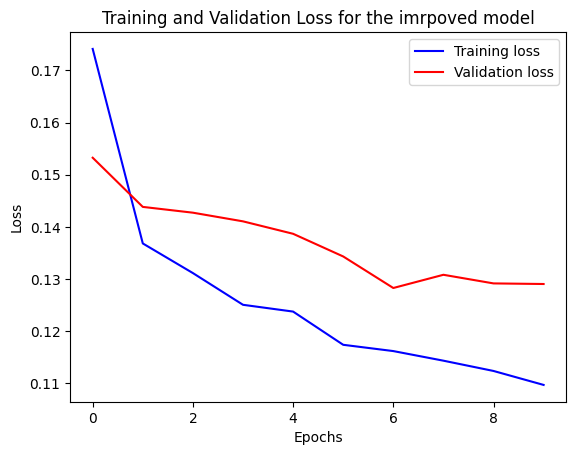

In [30]:
visualize_loss(history_improved, "Training and Validation Loss for the imrpoved model")

## Prediction

The new trained model above is now able to make predictions for 5 sets of values from
validation set.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


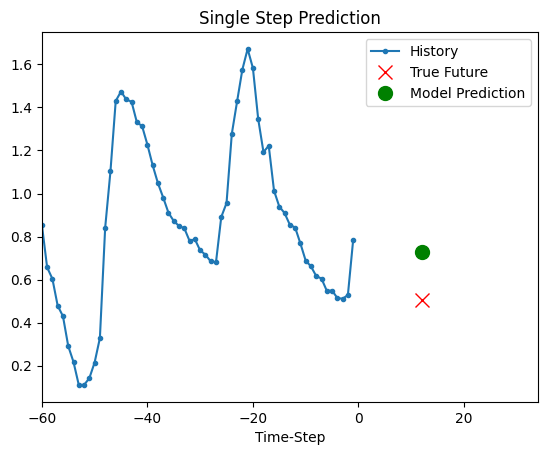

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


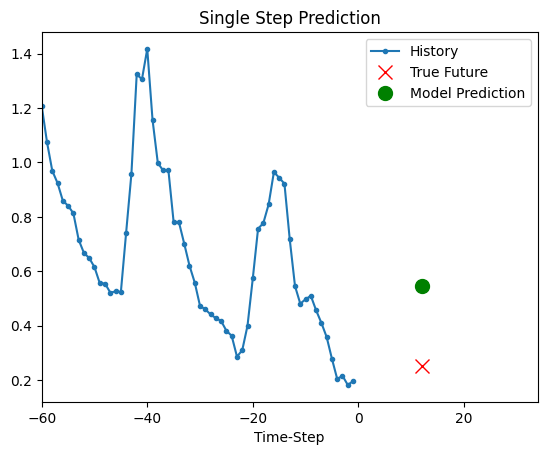

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


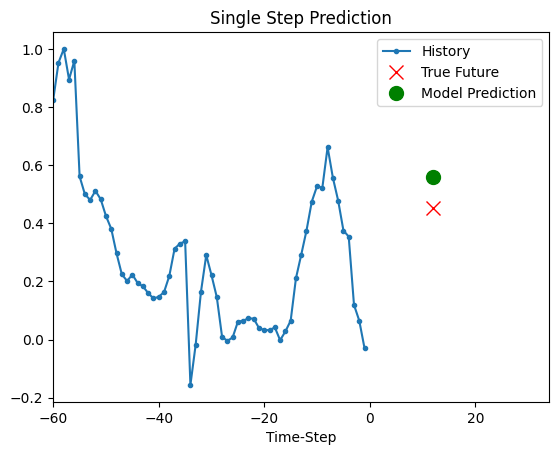

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


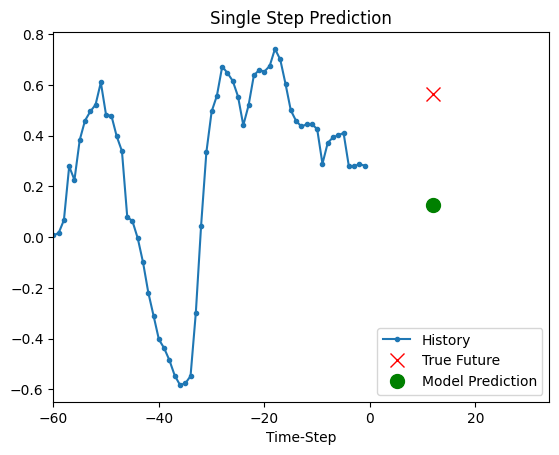

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


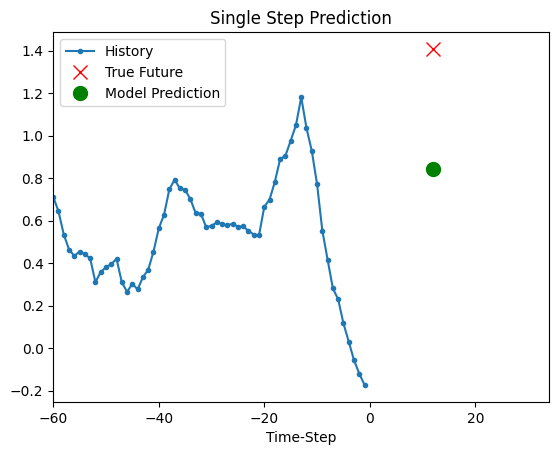

In [31]:
for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model_improved.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

## Evaluation

In [32]:
# Get true values
y_true = np.concatenate([y.numpy() for x, y in dataset_val], axis=0)
# Get predictions
y_pred = model_improved.predict(dataset_val)

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2  :", r2)

466/466 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step
MSE : 0.1290350887111049
MAE : 0.2818911406108959
RMSE: 0.35921454412524123
R^2  : 0.8431203952743823


# Comparison

| Metric | Baseline Model | Improved Model |
|--------|----------------|----------------|
| MSE    |     0.1375     |   0.1290       |
| MAE    |      0.2912    |   0.2819       |
| RMSE   |    0.3708      |   0.3592       |
| R²     |    0.8336      |   0.8431       |

The improved model shows consistent performance gains across all evaluation metrics compared to the baseline. The MSE decreased from 0.1375 to 0.1290 and the RMSE from 0.3708 to 0.3592, indicating a reduction in overall prediction error. Similarly, the MAE dropped from 0.2912 to 0.2819, showing that the average absolute deviation between predictions and true values has improved. Additionally, the R² score increased from 0.8336 to 0.8431, suggesting that the improved model explains a larger proportion of the variance in the data. Overall, these results demonstrate that the applied modifications lead to a more accurate and better-fitting model, with improved generalization to unseen data.